# Learning a LJ potential [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Teoroo-CMC/PiNN/blob/master/docs/notebooks/Learn_LJ_potential.ipynb)


This notebook showcases the usage of PiNN with a toy problem of learning a Lennard-Jones
potential with a hand-generated dataset.  
It serves as a basic test, and demonstration of the workflow with PiNN.

In [1]:
# Install PiNN
!pip install git+https://github.com/Teoroo-CMC/PiNN

  Cloning https://github.com/Teoroo-CMC/PiNN to /tmp/pip-req-build-a3b2xb3a
  Running command git clone --filter=blob:none --quiet https://github.com/Teoroo-CMC/PiNN /tmp/pip-req-build-a3b2xb3a
  Resolved https://github.com/Teoroo-CMC/PiNN to commit e40aab2e31a85aefbc13e0d5d24669a71954666d
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.8/82.8 kB 7.6 MB/s eta 0:00:00
  Created wheel for pinn: filename=pinn-1.2.0.dev0-py3-none-any.whl size=83606 sha256=44b8164dc05ecda8b26f9cbace0d2c82a5ff41a224849df8806c26a26c22e414
  Stored in directory: /tmp/pip-ephem-wheel-cache-caf_60j5/wheels/e4/ab/d6/bcd2a73748842ba163fcd986659948c7dcee63224645c4864d
Successfully built pinn
  Attempting uninstall: click
    Found existing installation: click 8.1.7
    Uninstalling click-8.1.7:
      Successfully uninstalled click-8.1.7
ERROR: pip's dependency resolver does not currently take into ac

In [3]:
%matplotlib inline

In [2]:
import os, warnings
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from ase import Atoms
from ase.calculators.lj import LennardJones
os.environ['CUDA_VISIBLE_DEVICES'] = ''
index_warning = 'Converting sparse IndexedSlices'
warnings.filterwarnings('ignore', index_warning)

## Reference data

In [4]:
# Helper function: get the position given PES dimension(s)
def three_body_sample(atoms, a, r):
    x = a * np.pi / 180
    pos = [[0, 0, 0],
           [0, 2, 0],
           [0, r*np.cos(x), r*np.sin(x)]]
    atoms.set_positions(pos)
    return atoms

In [5]:
atoms = Atoms('H3', calculator=LennardJones())

na, nr = 50, 50
arange = np.linspace(30,180,na)
rrange = np.linspace(1,3,nr)

# Truth
agrid, rgrid = np.meshgrid(arange, rrange)
egrid = np.zeros([na, nr])
for i in range(na):
    for j in range(nr):
        atoms = three_body_sample(atoms, arange[i], rrange[j])
        egrid[i,j] = atoms.get_potential_energy()

# Samples
nsample = 100
asample, rsample = [], []
distsample = []
data = {'e_data':[], 'f_data':[], 'elems':[], 'coord':[]}
for i in range(nsample):
    a, r = np.random.choice(arange), np.random.choice(rrange)
    atoms = three_body_sample(atoms, a, r)
    dist = atoms.get_all_distances()
    dist = dist[np.nonzero(dist)]
    data['e_data'].append(atoms.get_potential_energy())
    data['f_data'].append(atoms.get_forces())
    data['coord'].append(atoms.get_positions())
    data['elems'].append(atoms.numbers)
    asample.append(a)
    rsample.append(r)
    distsample.append(dist)

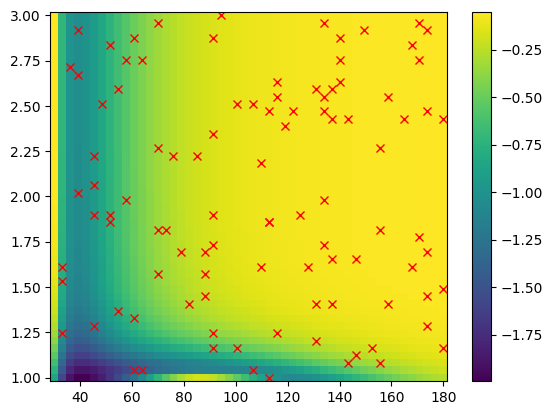

In [6]:
plt.pcolormesh(agrid, rgrid, egrid, shading='auto')
plt.plot(asample, rsample, 'rx')
plt.colorbar()

## Dataset from numpy arrays

In [7]:
from pinn.io import sparse_batch, load_numpy
data = {k:np.array(v) for k,v in data.items()}
dataset = lambda: load_numpy(data, splits={'train':8, 'test':2})

train = lambda: dataset()['train'].shuffle(100).repeat().apply(sparse_batch(100))
test = lambda: dataset()['test'].repeat().apply(sparse_batch(100))

In [22]:
data.keys()

dict_keys(['e_data', 'f_data', 'elems', 'coord'])

In [69]:
x

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.]])

[[0. 0. 0. 0.]
 [2. 2. 2. 2.]] [[ 0.          0.          0.          0.        ]
 [ 2.07227177 -0.92421671  2.19248863  0.54122746]]


(-2.0, 2.0)

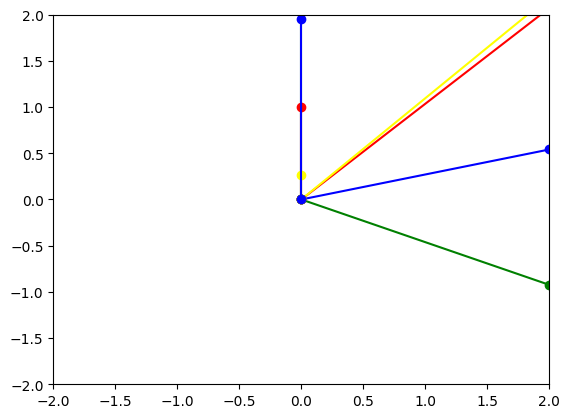

In [78]:
x, y = np.stack([[[0,0], data['coord'][np.random.choice(len(data['coord']))][1:,1]] for idx in range(4)]).T
print(x,y)
colors = ['red','green','yellow','blue']
for i in range(4):
  plt.plot(x[:,i],y[:,i],'o-',color=colors[i])
x, y = np.stack([[[0,0], data['coord'][np.random.choice(len(data['coord']))][1:,2]] for idx in range(4)]).T
for i in range(4):
  plt.plot(x[:,i],y[:,i],'o-',color=colors[i])
plt.xlim(-2,2)
plt.ylim(-2,2)


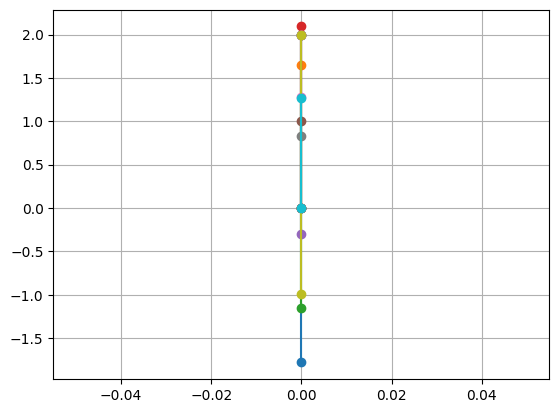

In [48]:
for i in range(5data):
  idx = np.random.choice(len(data['coord']))
  plt.plot([[0,0] for], data['coord'][idx][1:,1],'o-')
  # plt.plot([0,0], data['coord'][idx][1:,2],'o-')
plt.grid()

## Training

### Model specification

In [10]:
!pip uninstall tensorflow tensorboard tensorflow-estimator -y

Found existing installation: tensorflow 2.17.1
Uninstalling tensorflow-2.17.1:
  Successfully uninstalled tensorflow-2.17.1
Found existing installation: tensorboard 2.17.1
Uninstalling tensorboard-2.17.1:
  Successfully uninstalled tensorboard-2.17.1


In [15]:
!pip3 install tensorflow==2.15

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.16.0
    Uninstalling wrapt-1.16.0:
      Successfully uninstalled wrapt-1.16.0
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: keras
    Found existing installation: keras 3.5.0
    Uninstalling keras-3.5.0:
      Successfully uninstalled keras-3.5.0
ERROR: pip's dependency resolver does not currently take into acco

In [8]:
import pinn

params={
    'model_dir': '/tmp/PiNet',
    'network': {
        'name': 'PiNet',
        'params': {
            'ii_nodes':[8,8],
            'pi_nodes':[8,8],
            'pp_nodes':[8,8],
            'out_nodes':[8,8],
            'depth': 4,
            'rc': 3.0,
            'atom_types':[1]}},
    'model':{
        'name': 'potential_model',
        'params': {
            'e_dress': {1:-0.3},  # element-specific energy dress
            'e_scale': 2, # energy scale for prediction
            'e_unit': 1.0,  # output unit of energy dur
            'log_e_per_atom': True, # log e_per_atom and its distribution
            'use_force': True}}}      # include force in Loss function
model = pinn.get_model(params)

Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.


In [9]:
%rm -rf /tmp/PiNet
train_spec = tf.estimator.TrainSpec(input_fn=train, max_steps=5e3)
eval_spec = tf.estimator.EvalSpec(input_fn=test, steps=10)
tf.estimator.train_and_evaluate(model, train_spec, eval_spec)

Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use output_signature instead
Instructions for updating:
Use output_signature instead


3144 trainable vaiables, training with float32 precision.


Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.


({'METRICS/E_LOSS': 0.00037260237,
  'METRICS/E_MAE': 0.013621609,
  'METRICS/E_PER_ATOM_MAE': 0.0045405384,
  'METRICS/E_PER_ATOM_RMSE': 0.0064343032,
  'METRICS/E_RMSE': 0.01930291,
  'METRICS/F_LOSS': 0.013003044,
  'METRICS/F_MAE': 0.035973337,
  'METRICS/F_RMSE': 0.11403089,
  'loss': 0.0133756455,
  'global_step': 5000},
 [])

## Validate the results
### PES analysis

In [10]:
atoms = Atoms('H3', calculator=pinn.get_calc(model))
epred = np.zeros([na, nr])
for i in range(na):
    for j in range(nr):
        a, r = arange[i], rrange[j]
        atoms = three_body_sample(atoms, a, r)
        epred[i,j] = atoms.get_potential_energy()

Instructions for updating:
Use tf.keras instead.


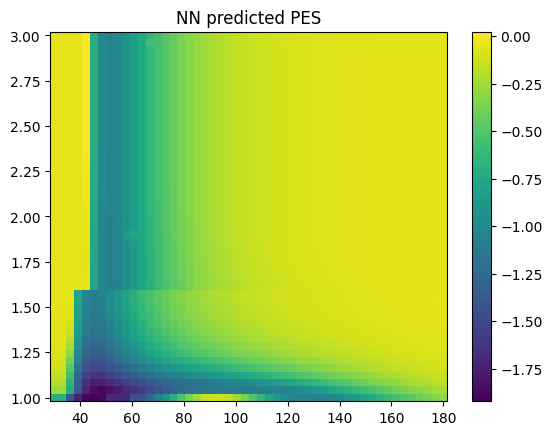

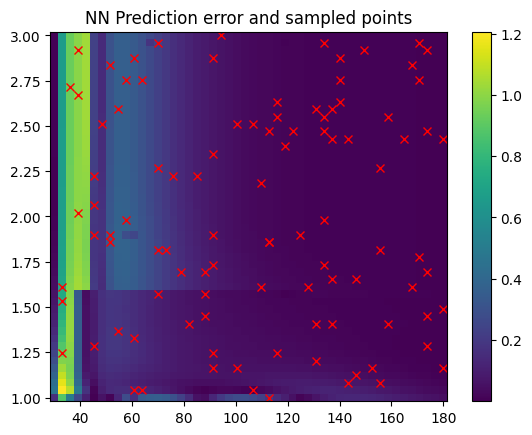

In [11]:
plt.pcolormesh(agrid, rgrid, epred, shading='auto')
plt.colorbar()
plt.title('NN predicted PES')
plt.figure()
plt.pcolormesh(agrid, rgrid, np.abs(egrid-epred), shading='auto')
plt.plot(asample, rsample, 'rx')
plt.title('NN Prediction error and sampled points')
plt.colorbar()

### Pairwise potential analysis

In [12]:
atoms1 = Atoms('H2', calculator=pinn.get_calc(model))
atoms2 = Atoms('H2', calculator=LennardJones())

nr2 = 100
rrange2 = np.linspace(1,1.9,nr2)
epred = np.zeros(nr2)
etrue = np.zeros(nr2)

for i in range(nr2):
    pos = [[0, 0, 0],
           [rrange2[i], 0, 0]]
    atoms1.set_positions(pos)
    atoms2.set_positions(pos)
    epred[i] = atoms1.get_potential_energy()
    etrue[i] = atoms2.get_potential_energy()

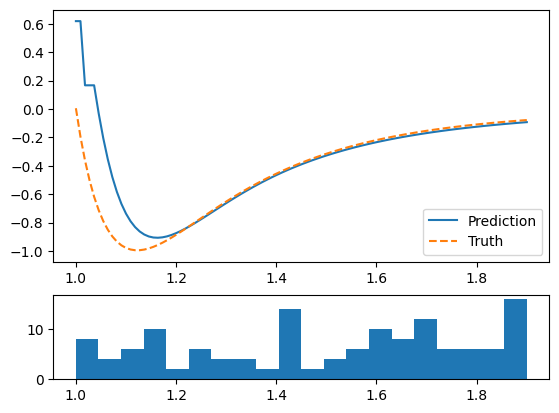

In [13]:
f, (ax1, ax2) = plt.subplots(2,1, gridspec_kw = {'height_ratios':[3, 1]})
ax1.plot(rrange2, epred)
ax1.plot(rrange2, etrue,'--')
ax1.legend(['Prediction', 'Truth'], loc=4)
_=ax2.hist(np.concatenate(distsample,0), 20, range=(1,1.9))

## Molecular dynamics with ASE

In [14]:
from ase import units
from ase.io import Trajectory
from ase.md.nvtberendsen import NVTBerendsen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution

In [15]:
atoms = Atoms('H', cell=[2, 2, 2], pbc=True)
atoms = atoms.repeat([5,5,5])
atoms.rattle()
atoms.set_calculator(pinn.get_calc(model))
MaxwellBoltzmannDistribution(atoms, 300*units.kB)
dyn = NVTBerendsen(atoms, 0.5 * units.fs, 300, taut=0.5*100*units.fs)
dyn.attach(Trajectory('ase_nvt.traj', 'w', atoms).write, interval=10)
dyn.run(5000)

/usr/local/lib/python3.10/dist-packages/ase/md/md.py:48: FutureWarning: Specify the temperature in K using the 'temperature_K' argument
  warnings.warn(FutureWarning(w))


True

In [16]:
d